In [ ]:
import tensorflow as tf
!pip install tf_agents
import tf_agents
from tf_agents.bandits.environments import movielens_py_environment
from tf_agents.environments import tf_py_environment
from tf_agents.bandits.environments import environment_utilities
from tf_agents.bandits.metrics import tf_metrics as tf_bandit_metrics
from tf_agents.bandits.agents import lin_ucb_agent
from tf_agents.bandits.agents import linear_thompson_sampling_agent as lin_ts_agent
from tf_agents.networks import q_network
from tf_agents.bandits.agents import neural_epsilon_greedy_agent as eps_greedy_agent
from tf_agents.bandits.agents.examples.v2 import trainer
from tf_agents.replay_buffers import tf_uniform_replay_buffer
from tf_agents.drivers import driver
from tf_agents.drivers import dynamic_step_driver
from tf_agents.policies import random_tf_policy
import functools
import os
import numpy as np
from matplotlib import pyplot as plt
from tf_agents.bandits.environments import movielens_py_environment

# 1.Write down the “Movie Recommendation” as a Reinforcement Learning problem formulation. Use comment lines for proper documentation.


In movie recommendation, the goal is to recommend movies to users in a way that maximizes user satisfaction or engagement. We can formulate this as a contextual bandit problem, where the agent (recommendation system) interacts with the environment (users and available movies) over multiple time steps. At each time step, the agent observes a context (user features) and selects an action (movie recommendation) based on the observed context and historical data. The environment provides a reward based on the action taken, which reflects the user's satisfaction with the recommended movie.

1. State:
    - The state consists of user features or context, such as user preferences, demographics, past interactions, etc.
    - It can also include information about the available movies, such as genres, ratings, popularity, etc.
    - The state is represented as a feature vector or embedding.

2. Action:
    - The action represents the movie recommendation chosen by the agent.
    - Each action corresponds to recommending a specific movie from the available set of movies.

3. Reward:
    - The reward indicates the user's satisfaction or engagement with the recommended movie.
    - It can be binary (e.g., 1 for a satisfied user, 0 otherwise) or continuous (e.g., rating given by the user).
    - The reward function is typically defined based on user feedback or interactions, such as ratings, clicks, watch time, etc.

4. Policy:
    - The policy is the decision-making strategy used by the agent to select actions given the observed state.
    - It maps states to actions and can be stochastic or deterministic.
    - The goal is to learn an optimal policy that maximizes the cumulative reward over time.

5. Environment:
    - The environment consists of users and available movies.
    - It generates user contexts, provides rewards based on user interactions, and updates its internal state based on agent actions.

6. Exploration-Exploitation Tradeoff:
    - The agent faces the exploration-exploitation dilemma, balancing between exploring new movie recommendations to gather information and exploiting known recommendations to maximize short-term reward.
    - Various exploration strategies (e.g., epsilon-greedy, Thompson sampling) can be used to address this tradeoff.

7. Learning:
    - Reinforcement learning algorithms are used to train the agent to learn an optimal policy.
    - Algorithms such as contextual bandits, deep Q-learning, policy gradients, etc., can be employed depending on the complexity of the problem and available data.

8. Evaluation:
    - The performance of the recommendation system is evaluated based on metrics such as user satisfaction, click-through rate, conversion rate, etc.
    - Offline evaluation using historical data and online A/B testing can be used to assess the effectiveness of the system.


# 2. For the environment, use the built-in TF-agent agent,MovieLensPyEnvironment (non-per-arm)

In [30]:
### https://github.com/tensorflow/agents/blob/master/tf_agents/bandits/environments/movielens_py_environment.py

BATCH_SIZE = 8
TRAINING_LOOPS = 500
STEPS_PER_LOOP = 2
RANK_K = 20
NUM_ACTIONS = 20

data_path = 'u.data'

In [14]:
env = movielens_py_environment.MovieLensPyEnvironment(
        data_path,
        RANK_K,
        BATCH_SIZE,
        num_movies=NUM_ACTIONS,
        csv_delimiter='\t')
environment = tf_py_environment.TFPyEnvironment(env)

In [15]:
optimal_reward_fn = functools.partial(
      environment_utilities.compute_optimal_reward_with_movielens_environment,
      environment=environment)


optimal_action_fn = functools.partial(
      environment_utilities.compute_optimal_action_with_movielens_environment,
      environment=environment)

In [16]:
AGENT_ALPHA = 10.0
linucb = lin_ucb_agent.LinearUCBAgent(
        time_step_spec=environment.time_step_spec(),
        action_spec=environment.action_spec(),
        tikhonov_weight=0.001,
        alpha=AGENT_ALPHA,
        dtype=tf.float32,
        accepts_per_arm_features=False)
     

2024-02-24 10:31:44.367944: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-02-24 10:31:44.485911: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [17]:
lints = lin_ts_agent.LinearThompsonSamplingAgent(
        time_step_spec=environment.time_step_spec(),
        action_spec=environment.action_spec(),
        dtype=tf.float32,
        accepts_per_arm_features=False)

In [18]:
EPSILON = 0.05
LAYERS = (50, 50, 50)
LR = 0.005

network = q_network.QNetwork(
          input_tensor_spec=environment.time_step_spec().observation,
          action_spec=environment.action_spec(),
          fc_layer_params=LAYERS)

neureps = eps_greedy_agent.NeuralEpsilonGreedyAgent(
        time_step_spec=environment.time_step_spec(),
        action_spec=environment.action_spec(),
        reward_network=network,
        optimizer=tf.compat.v1.train.AdamOptimizer(learning_rate=LR),
        epsilon=EPSILON,
        emit_policy_info='predicted_rewards_mean',
        info_fields_to_inherit_from_greedy=['predicted_rewards_mean'])

# 3. Compute the regret using the built-in metric in TF-agents

In [31]:
### https://github.com/tensorflow/agents/blob/master/tf_agents/bandits/metrics/tf_metrics.py

regret_metric = tf_bandit_metrics.RegretMetric(optimal_reward_fn)
suboptimal_arms_metric = tf_bandit_metrics.SuboptimalArmsMetric(optimal_action_fn)

# 4.Plot the regret against 20,000-time steps using the built-in agents:
I. LinUCB
II. LinTS
III. NeuralEpsilonGreedy

In [32]:
def train(agent):

  if agent == 'LinUCB':
    agent = linucb
  elif agent == 'LinTS':
    agent = lints
  elif agent == 'NeurEps':
    agent = neureps


  replay_buffer = tf_uniform_replay_buffer.TFUniformReplayBuffer(
    data_spec=agent.policy.trajectory_spec,
    batch_size=BATCH_SIZE,
    max_length=STEPS_PER_LOOP)

  observers = [replay_buffer.add_batch, regret_metric]

  driver = dynamic_step_driver.DynamicStepDriver(
      env=environment,
      policy=agent.collect_policy,
      num_steps=STEPS_PER_LOOP * BATCH_SIZE,
      observers=observers)

  regret_values = []

  for _ in range(TRAINING_LOOPS):
    driver.run()
    loss_info = agent.train(replay_buffer.gather_all())
    replay_buffer.clear()
    regret_values.append(regret_metric.result())

  return regret_values, agent

Instructions for updating:
Use `as_dataset(..., single_deterministic_pass=True)` instead.


Text(0, 0.5, 'Average Regret')

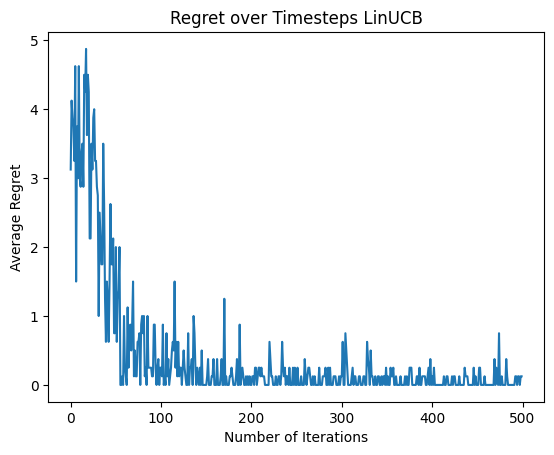

In [21]:
regret_values_linucb, linucb_agent = train('LinUCB')
plt.plot(regret_values_linucb)
plt.title('Regret over Timesteps LinUCB')
plt.xlabel('Number of Iterations')
plt.ylabel('Average Regret')

In [23]:
sum(regret_values_linucb)

<tf.Tensor: shape=(), dtype=float32, numpy=213.0>

Text(0, 0.5, 'Average Regret')

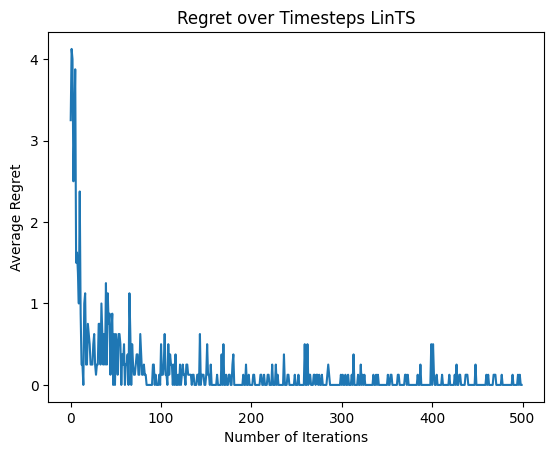

In [24]:
regret_values_lints, lints_agent = train('LinTS')
plt.plot(regret_values_lints)
plt.title('Regret over Timesteps LinTS')
plt.xlabel('Number of Iterations')
plt.ylabel('Average Regret')
plt.show()

In [25]:
sum(regret_values_lints)

<tf.Tensor: shape=(), dtype=float32, numpy=83.125>

Text(0, 0.5, 'Average Regret')

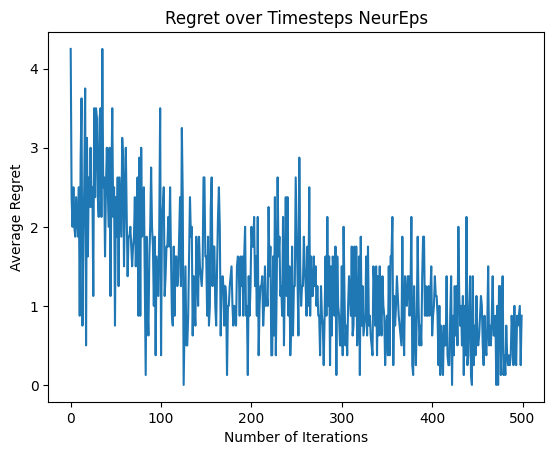

In [26]:
regret_values_neureps, neureps_agent = train('NeurEps')
plt.plot(regret_values_neureps)
plt.title('Regret over Timesteps NeurEps')
plt.xlabel('Number of Iterations')
plt.ylabel('Average Regret')
plt.show()

In [27]:
sum(regret_values_neureps)

<tf.Tensor: shape=(), dtype=float32, numpy=656.875>

In [28]:
def recommend_movies(agent, observation):
    time_step = tf_agents.trajectories.time_step.TimeStep(
        step_type=tf.constant([[2]], dtype=tf.int32),
        reward=tf.constant([[0.0]], dtype=tf.float32),
        discount=tf.constant([[1.0]], dtype=tf.float32),
        observation=observation)
    
    action_step = agent.policy.action(time_step)
    return action_step.action.numpy()[0]

# 5. Write the Recommendation policy; given a new observation request (i.e., a user vector),the policy will produce actions, which are the recommended movies.

In [29]:
observation = np.array([1, 25, 35, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1])
observation = np.expand_dims(observation, axis=0)
recommend_movies(lints_agent, observation=observation)

13